Tuần 2 - Khám phá dữ liệu (EDA)

Import thư viện và Load Data

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cố định random seed theo yêu cầu (Code Quality)
np.random.seed(42)

# Thiết lập style cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid", palette="muted")

# Đọc dữ liệu
df = pd.read_csv('../../data/insurance.csv')

# Xem thông tin cơ bản
display(df.head())
display(df.info())
display(df.describe())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


None

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Kiểm tra dữ liệu trùng lặp (Duplicates)

In [9]:
duplicates = df.duplicated().sum()
print(f"Số dòng trùng lặp: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Đã xóa các dòng trùng lặp.")

Số dòng trùng lặp: 1
Đã xóa các dòng trùng lặp.


**Yêu cầu 1: Phân tích biến mục tiêu (Target Analysis) - Biểu đồ 1**

Biến mục tiêu của chúng ta là charges (Chi phí bảo hiểm y tế).

Distribution của biến Charges

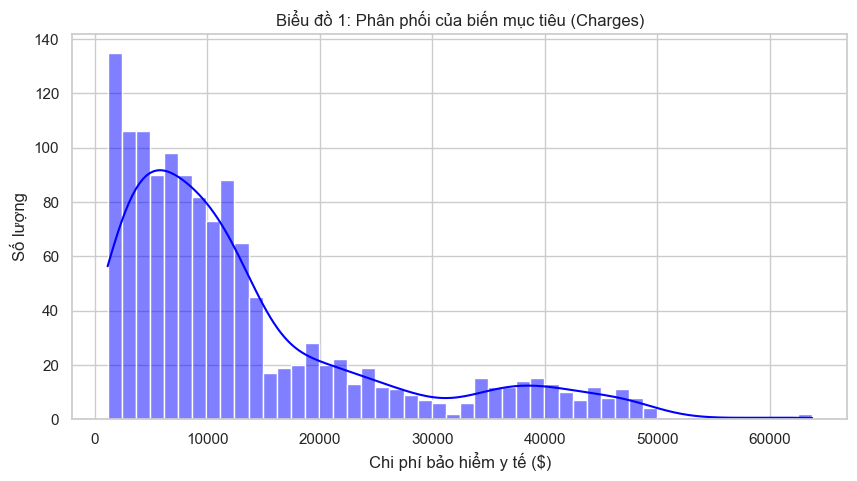

Độ lệch (Skewness) của Charges: 1.52


In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['charges'], kde=True, bins=50, color='blue')
plt.title('Biểu đồ 1: Phân phối của biến mục tiêu (Charges)')
plt.xlabel('Chi phí bảo hiểm y tế ($)')
plt.ylabel('Số lượng')
plt.show()

# Tính độ lệch (Skewness)
print(f"Độ lệch (Skewness) của Charges: {df['charges'].skew():.2f}")